In [1]:
from sklearn.manifold import TSNE
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import time

## Cargar los datos

In [2]:
# Load the digits dataset
digits = load_digits()
X_digits = digits.data
y_digits = digits.target
n_samples, n_features = X_digits.shape
n_classes = len(np.unique(y_digits))
print(f"Dataset: {n_samples} samples with {n_features} features")
print(f"Number of classes: {n_classes}")

Dataset: 1797 samples with 64 features
Number of classes: 10


## Mostrar alguno de los dígitos al azar

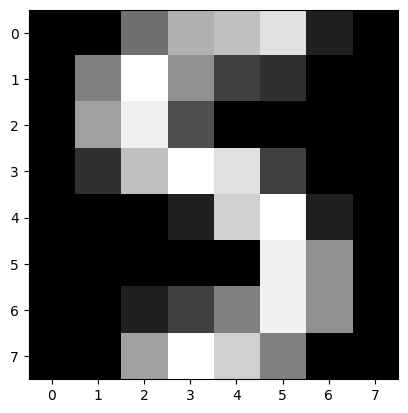

In [7]:
idx = np.random.choice(n_samples)
plt.imshow(X_digits[idx].reshape((8,8)), cmap="gray")
plt.show()

## Estandarización

In [4]:
# Standardize the data (important for t-SNE)
scaler = StandardScaler()
X_digits_scaled = scaler.fit_transform(X_digits)

## Aplicar t-SNE

In [5]:
# Apply t-SNE with default parameters
# Perplexity is related to the number of nearest neighbors that is used.
# Larger datasets usually require a larger perplexity.
# Consider selecting a value between 5 and 50.
# Different values can result in significantly different results. The perplexity must be less than the number of samples.
start_time = time.time()
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_digits_tsne = tsne.fit_transform(X_digits_scaled)
end_time = time.time()
print(f"Tiempo de cálculo: {end_time-start_time:.1f} s")

Tiempo de cálculo: 3.5 s


## Visualizar el resultado (usando primeras dos componentes t-SNE)

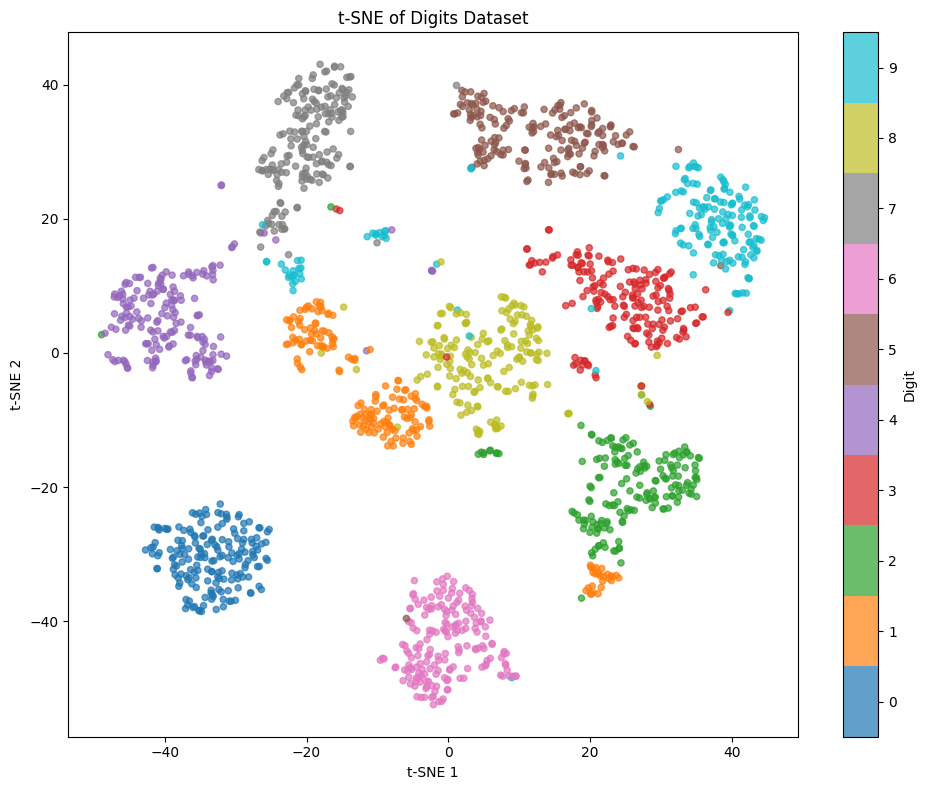

In [6]:
# Visualize the t-SNE results
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_digits_tsne[:, 0], X_digits_tsne[:, 1], c=y_digits, cmap='tab10', alpha=0.7, s=20)
plt.title('t-SNE of Digits Dataset')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
tick_positions = [(i+0.5)*9/10 for i in range(10)]
tick_labels = range(10)
cbar = plt.colorbar(scatter, label='Digit', ticks=tick_positions)
cbar.ax.set_yticklabels(tick_labels)
plt.tight_layout()
plt.show()